In [1]:
BasePath = joinpath(homedir(),"jupyter","julia","sivers") 
ModulePath = joinpath(BasePath,"sivers.jl") 
include(ModulePath)
using .Sivers

# Parameters handled separately
ParametersPath = joinpath(BasePath,"parameters.jl")
include(ParametersPath)
using .parameters: params
# # Parameters and SU(Nc) algebra set in parameters.jl
alpha_s = params.alpha_s
Nc = params.Nc
mN = params.mN
mq = params.mq
dabc2 = (Nc^2 - 4) * (Nc^2 - 1) / Nc ;

In [3]:
# Test spin sums in forward limit
function test_spin_sum(s01,s02)
    # Initialize wavefunctions
    swf1 = Array{ComplexF64}(undef, 2, 2, 2)
    swf2 = Array{ComplexF64}(undef, 2, 2, 2)
    x = rand(2) 
    (x1, x2, x3), d2x = hp.cuba_to_parton_x(x[1:2])
    # Forward limit
    k1, k2, k3 =[0,0], [0,0], [0,0]

    for s1 in (-1,1), s2 in (-1,1), s3 in (-1,1)
        i1 = hp.spin_index(s1)
        i2 = hp.spin_index(s2)
        i3 = hp.spin_index(s3)
        swf1[i1,i2,i3] = spin_wavefunction(s01,s1,s2,s3,k1, k2, k3, x1, x2, x3)
        swf2[i1,i2,i3] = spin_wavefunction(s02,s1,s2,s3,k1, k2, k3, x1, x2, x3)
    end
    result = spin_sum(swf1,swf2)
    return result
end
# Should be 1 in forward limit
println(test_spin_sum(1,1))
# Should be 0 in forward limit
println(test_spin_sum(1,-1))

1.0000000000000002 + 0.0im
0.0 + 0.0im


$F_2$ form factor

In [ ]:
# Something's fishy already here...check this
# probably a sign error

In [ ]:
Δ = [1,0]
fdu = f_form_factor(1,-1,Δ)
fud = f_form_factor(-1,1,Δ)

In [ ]:
ΔL, ΔR = complex(Δ[1],-Δ[2]) / sqrt(2), complex(Δ[1],Δ[2]) / sqrt(2)
Δ2 = sum(Δ.^2)
result = 2 * mN^2 / Δ2 * (ΔL / mN * fdu - ΔR / mN * fud)
println(result)

-2.5007324264722348e-17 - 1.7755335368382395e-17im


In [ ]:
Δ_array = 0:.125:3.3
n = length(Δ_array)
# Initialize array
results = Vector{ComplexF64}(undef, n)
for i in 1:n
    Δ = Δ_array[i]
    results[i] = f2_form_factor([Δ, 0.0])
end
println(results)

ComplexF64[NaN + NaN*im, 0.008504613604797253 + 2.5743233963630374e-17im, -5.9941012992728916e-5 + 1.3158929860659489e-17im, -0.016312852760178725 + 9.806946271841356e-18im, -0.0016016953150959849 - 5.171631823050764e-19im, 0.0012934909535739665 + 5.354395816983772e-30im, 0.0017987305558940638 - 1.9290949045193014e-32im, 0.0012546957741499645 - 4.202976973646296e-18im, 0.0011217011042797783 - 2.7127897094802676e-33im, -1.9801045401606664e-5 + 6.5890420264054005e-18im, -2.100830723967007e-5 + 1.0297293585452126e-17im, 9.869052871014902e-6 - 2.674621710507046e-18im, -0.00031439348064932465 + 1.1032814555842695e-17im, -2.466637995222501e-5 + 2.2631414473520985e-18im, 1.5351561539047167e-5 - 1.0507442434144388e-18im, 5.288041660736139e-5 + 9.806946271859184e-19im, 3.231621261493076e-5 + 3.6776048519472e-18im, -2.773842406990878e-5 + 8.653187886934503e-19im, 1.334667263166878e-5 + 6.129341419911909e-19im, -1.0961660442959813e-5 - 1.9355815010244916e-18im, -2.0712942286748047e-5 - 2.02268266

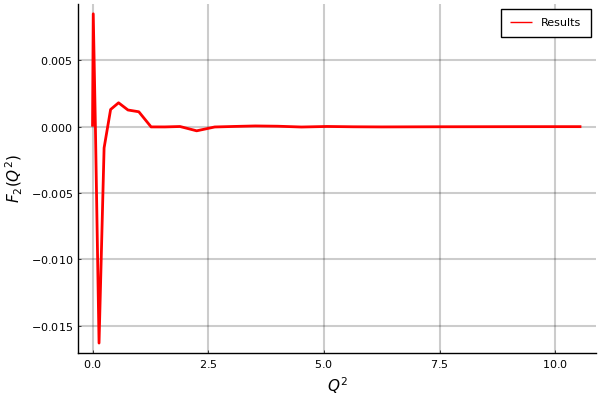

In [ ]:
using Plots, LaTeXStrings
pyplot()
Q2 = Δ_array.^2

plot(Q2, real(results),
    label="Results",              # Label for the data series
    xlabel=L"Q^2",             # Label for the x-axis
    ylabel=L"F_2(Q^2)",       # Label for the y-axis
    markersize=5,                 # Optional: Set marker size
    markercolor=:blue,            # Optional: Set marker color
    linewidth=2,                  # Optional: Set line width
    linecolor=:red,                # Optional: Set line color (if not using :scatter, or to connect points)
    # yscale=:log10,
    gridalpha=0.2,        # Increase opacity (0.0=invisible, 1.0=solid)
    gridlinewidth=1.5,    # Increase line thickness (default is often < 1)
)

In [ ]:
############################################################################
############################################################################
###   ___  _     _       _          __  __   _          _                ###
###  / _ \| | __| |  ___| |_ _   _ / _|/ _| | |__   ___| | _____      __ ###
### | | | | |/ _` | / __| __| | | | |_| |_  | '_ \ / _ \ |/ _ \ \ /\ / / ###
### | |_| | | (_| | \__ \ |_| |_| |  _|  _| | |_) |  __/ | (_) \ V  V /  ###
###  \___/|_|\__,_| |___/\__|\__,_|_| |_|   |_.__/ \___|_|\___/ \_/\_/   ###
###                                                                      ###
############################################################################
############################################################################

$F_1$ form factor

In [ ]:
Δ_array = 0:.125:3.3
n = length(Δ_array)
# Initialize array
results = Vector{ComplexF64}(undef, n)
for i in 1:n
    Δ = Δ_array[i]
    results[i] = f1_form_factor([Δ, 0.0])
end
println(results)

ComplexF64[1.0000000000000044 + 0.0im, 0.9604490679141829 - 2.018614566574708e-18im, 0.850140286976768 - 8.035573000122411e-19im, 0.7092041767258853 - 1.6452577683509454e-18im, 0.561825672127043 + 7.929997421146725e-19im, 0.42910843161984097 + 2.4274118040275665e-18im, 0.32089306128678813 + 2.940549529951652e-19im, 0.24013004381392203 + 1.1458122591116201e-18im, 0.17262841987798141 + 1.469969846070028e-18im, 0.12392366479880186 + 4.4320561753591435e-18im, 0.08858122725959695 + 3.2525193308682457e-18im, 0.06324049271989429 + 3.2093481258657e-18im, 0.04490346479027737 + 1.0347574952190376e-17im, 0.03139680738800068 + 8.524505193014835e-18im, 0.022185947686009316 + 1.325517624123591e-17im, 0.01606744925762214 + 2.2177049615549194e-17im, 0.011447521703007106 + 2.4049212953564428e-17im, 0.00819399098751722 + 2.4598831414304972e-17im, 0.005851943525568586 + 1.6208172045365398e-17im, 0.004277207798958424 + 1.7774747458882134e-17im, 0.00273776725587325 + 1.277529133406734e-17im, 0.001953952429

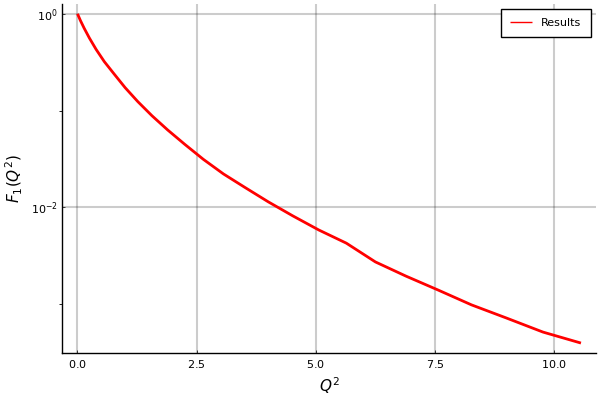

In [52]:
using Plots, LaTeXStrings
pyplot()
Q2 = Δ_array.^2

plot(Q2, real(results),
    label="Results",              # Label for the data series
    xlabel=L"Q^2",             # Label for the x-axis
    ylabel=L"F_1(Q^2)",       # Label for the y-axis
    markersize=5,                 # Optional: Set marker size
    markercolor=:blue,            # Optional: Set marker color
    linewidth=2,                  # Optional: Set line width
    linecolor=:red,                # Optional: Set line color (if not using :scatter, or to connect points)
    yscale=:log10,
    gridalpha=0.2,        # Increase opacity (0.0=invisible, 1.0=solid)
    gridlinewidth=1.5,    # Increase line thickness (default is often < 1)
)

Proton radius

Linearized result:
  Proton radius R[fm] = 0.7696815452862754
Dipole fit result:
  M_D = 0.577752650493521
  Proton radius R[fm] = 0.8373379573186447
  Uncertainty: M_D^2 ± 0.007040636120621803, R ± 0.04471278170191824


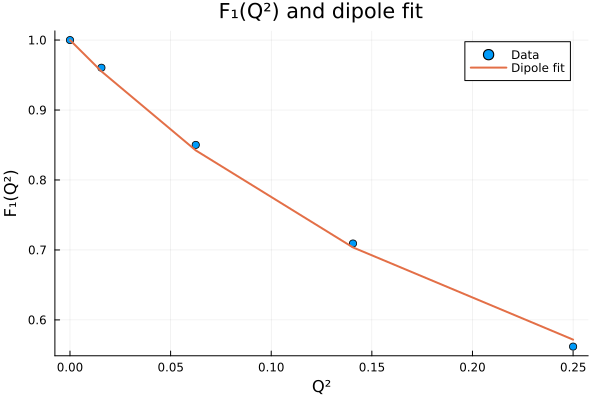

In [ ]:
using LsqFit, Plots
Q2_array = Δ_array.^2
F1 = real(results)

# Linearized derivative
println("Linearized result:")
dF_qQ2 = (F1[2] - F1[1]) / (Q2_array[2] - Q2_array[1])
R = sqrt(-6 * dF) 
println("  Proton radius R[fm] = ", R * hbarc)

# Restrict to Q^2 ≤ Qmax2
Qmax2 = 0.28
mask = Q2_array .<= Qmax2
x = Q2_array[mask]
y = F1[mask]

# Dipole model: p[1] = M_D^2
# model(x,p) = 1.0 ./ (1 .+ x ./ p[1])
# More elegant way to write
@. model(x,p) = 1.0 / (1 + x / p[1])

# Initial guess for M_D^2 (~0.71 GeV^2 for proton)
p0 = [0.7]

fit = curve_fit(model, x, y, p0)

MD2 = fit.param[1]
R = sqrt(6 / MD2) 
hbarc = 0.1975

println("Dipole fit result:")
println("  M_D = ", sqrt(MD2))
println("  Proton radius R[fm] = ", R * hbarc)

# Error estimate
cov = estimate_covar(fit)
σ_MD2 = sqrt(cov[1,1])
σ_R = 0.5 * sqrt(6) * σ_MD2 / (MD2^(3/2))
println("  Uncertainty: M_D^2 ± ", σ_MD2, ", R ± ", σ_R)

F1_fit = model(x, fit.param)

plot(x, y, seriestype=:scatter, label="Data", xlabel="Q²", ylabel="F₁(Q²)",
     title="F₁(Q²) and dipole fit", legend=:topright)
plot!(x, F1_fit, label="Dipole fit", lw=2)


Benchmark tests

Things I have tried to speed up:
- Summation outside integrand and summing contributions obtained by cuhre slightly faster
- Summation inside integrand is slightly slower
- Parallelizing with CUBACORES actually takes longer
- No speed up with parallelization in general

In [ ]:
using Cuba
using BenchmarkTools
"""
    cuba_to_polar(x)

Transform a Cuba sample `x ∈ [0,1]^2` into polar coordinates.

# Arguments
- `x::Vector{<:Real}`: Sample point in the unit circle `[0,1]^2`.

# Returns
- `r::Real`: Radius
- `ϕ::Real`: Azimuthal angle
- `jac::Real`: Jacobian determinant of the transformation

# Notes
Throws an `ArgumentError` if called with `length(x) != 2`.
"""
function cuba_to_polar(x::Vector{<:Real})
    n = length(x)            
    if n != 2
        throw(ArgumentError("Input must be two-dimensional for polar coordinates"))
    end
    # r ∈ [0, ∞)
    r = x[1] / (1 - x[1])
    drdx = 1 / (1 - x[1])^2
    ϕ = 2π * x[2]
    jac = 2π * r * drdx

    return r, ϕ, jac
end

function cuba_to_hyperspherical(x::Vector{<:Real})
    n = length(x)            
    if n < 2
        throw(ArgumentError("Need at least 2 dimensions for hyperspherical coordinates"))
    end

    # r ∈ [0, ∞)
    r = x[1] / (1 - x[1])
    drdx = 1 / (1 - x[1])^2

    thetas = zeros(eltype(x), n-1)

    jac = r^(n-1) * drdx

    # first n-2 angles in [0, π]
    for i in 1:(n-2)
        cosθ = 2*x[i+1] - 1
        θ = acos(cosθ)
        thetas[i] = θ
        jac *= 2 * sin(θ)^(n-i-2)
    end

    # last angle in [0,2π)
    ϕ = 2π * x[n]
    thetas[end] = ϕ
    jac *= 2π

    return r, thetas, jac
end

function integrand(x,f)
    r1, ϕ1, d2k1 = cuba_to_polar(x)
    f[1] = exp(-r1^2) * d2k1
end
@btime integral, err = cuhre(integrand,2,1)
println(integral[1])

function integrand(x,f)
    r1, (ϕ1,), d2k1 = cuba_to_hyperspherical(x)
    f[1] = exp(-r1^2) * d2k1
end

@btime integral, err = cuhre(integrand,2,1)
println(integral[1])


  46.419 μs (2343 allocations: 73.31 KiB)
3.141592697100627
  59.469 μs (2928 allocations: 109.88 KiB)
3.141592697100627
